### Loading Data

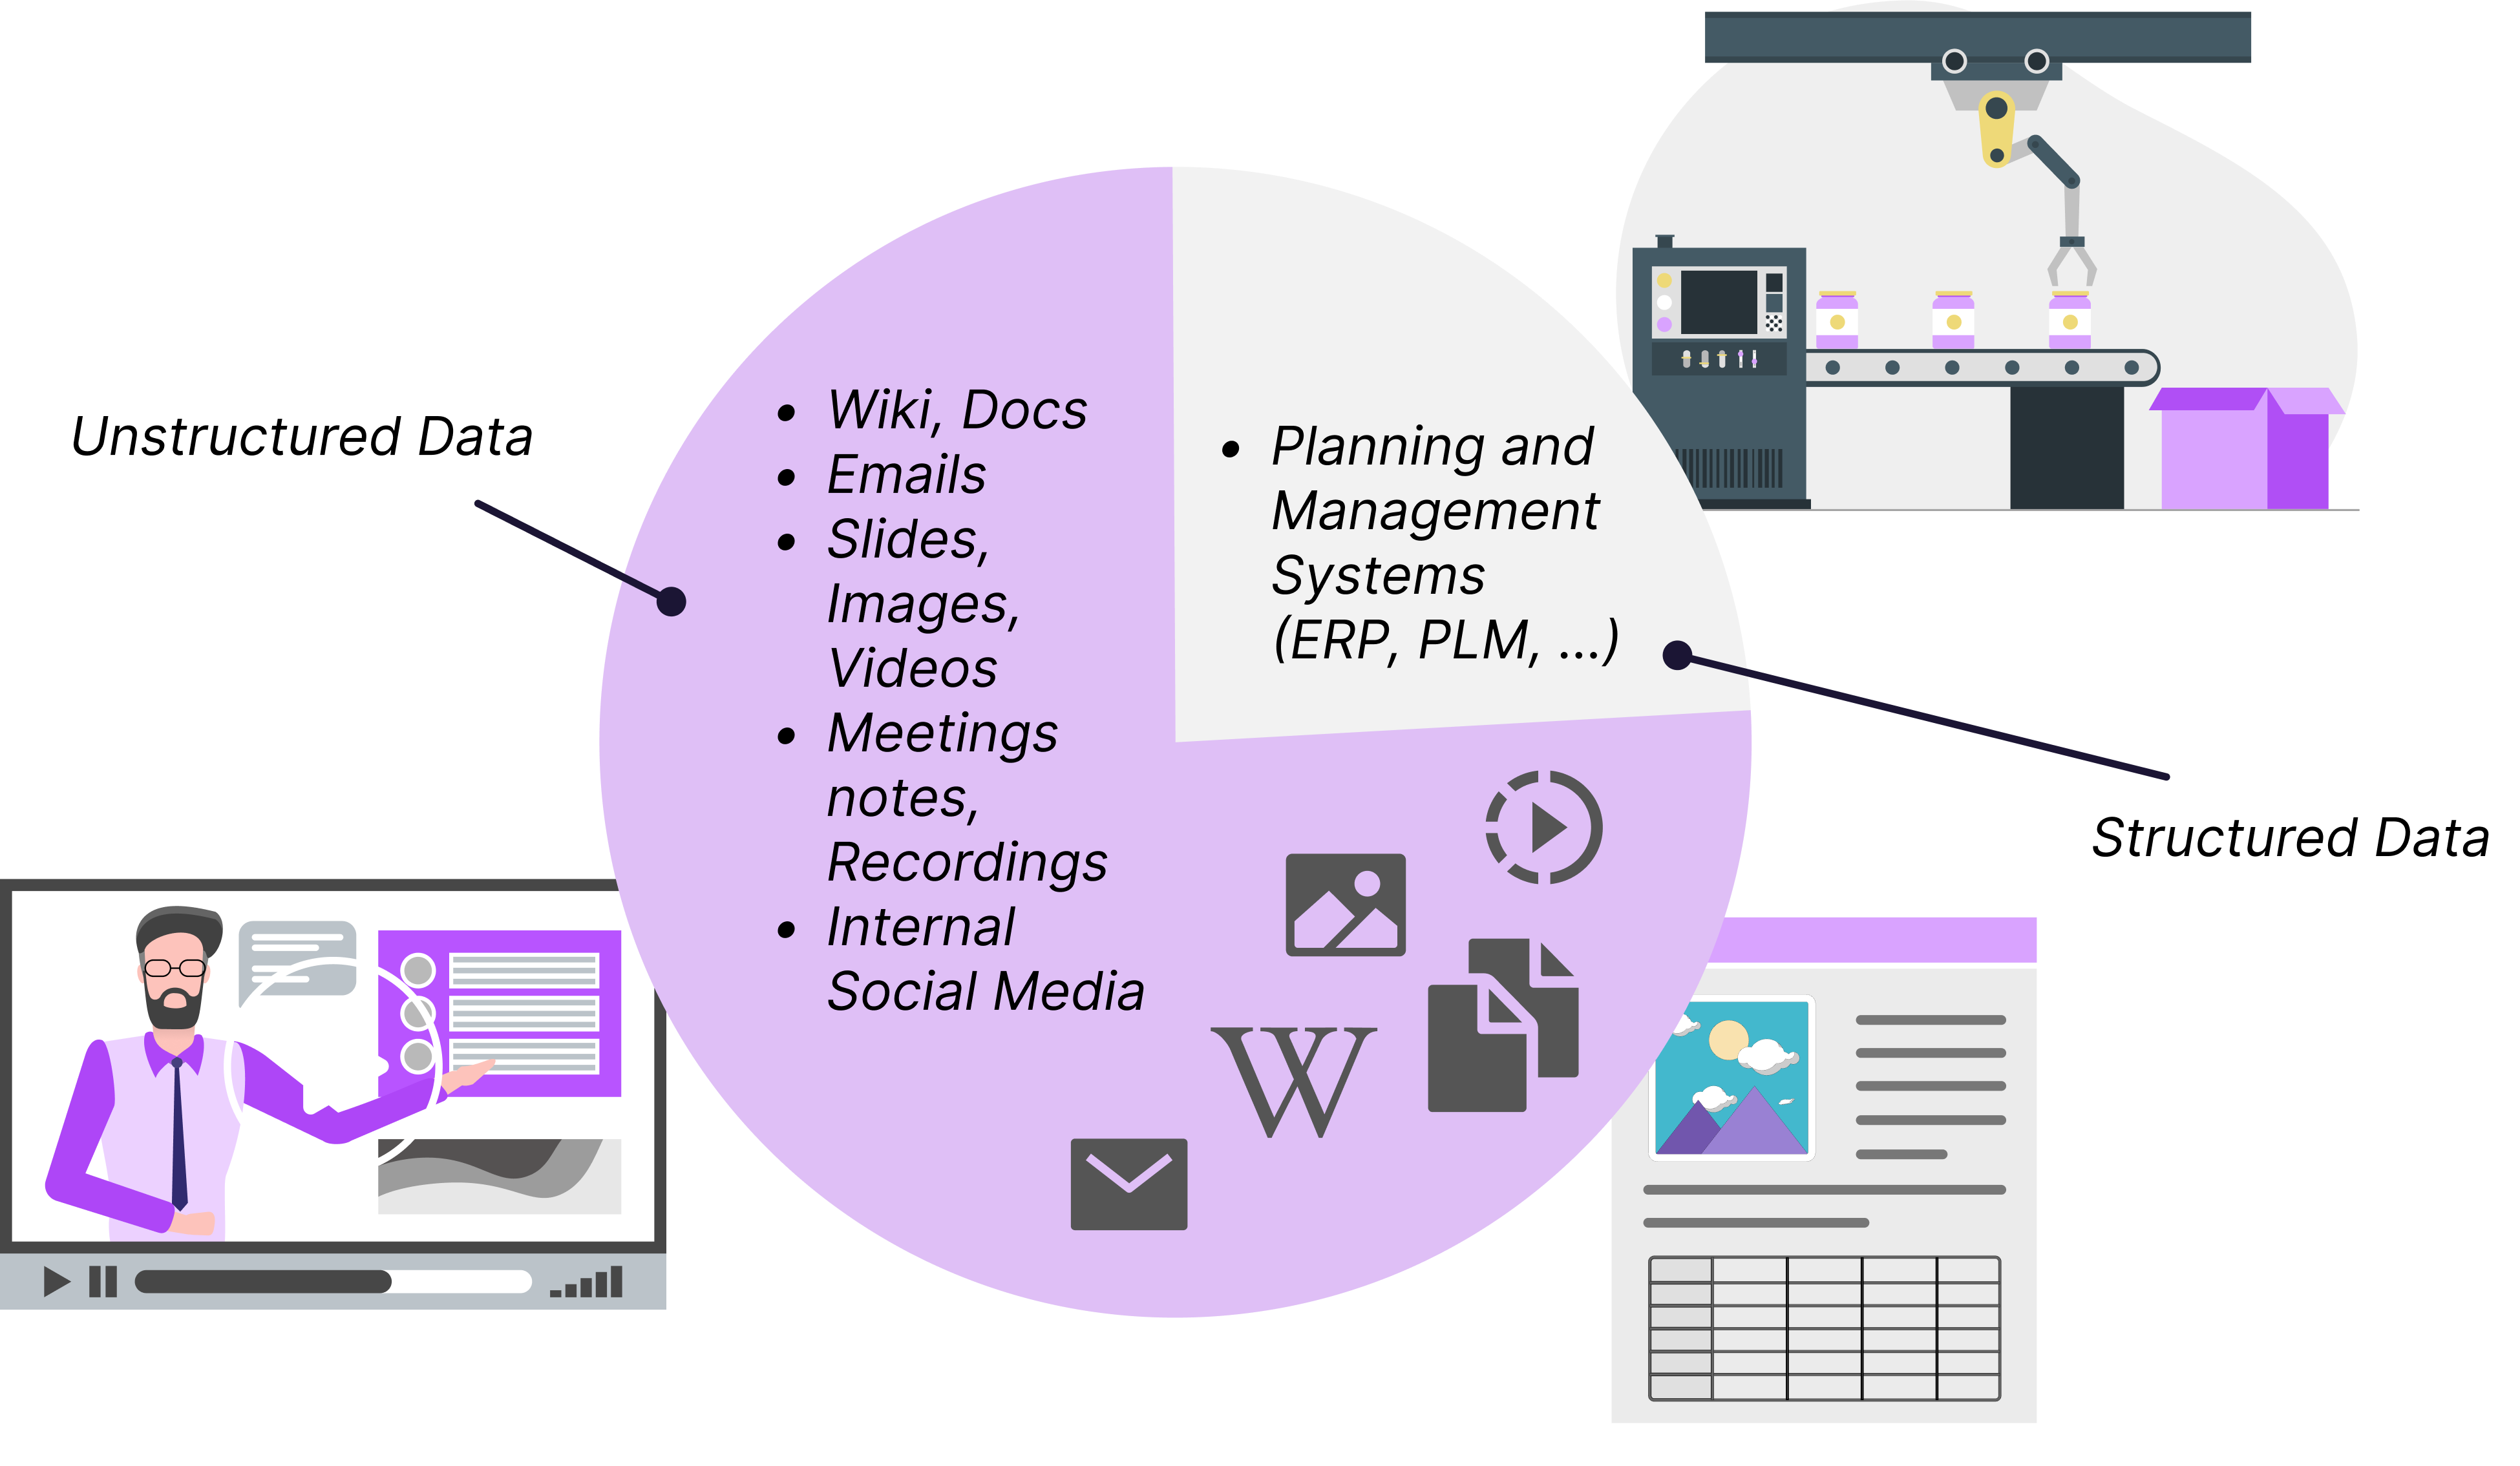

In [1]:
from IPython.display import Image, display
display(Image(filename="images/rwpc_0301.png", width=500, height=500))

This chapter shows how to turn common data sources into text you can embed and retrieve. Most RAG retrievers work with text embeddings, so a practical first step is to convert different formats into a consistent text representation.

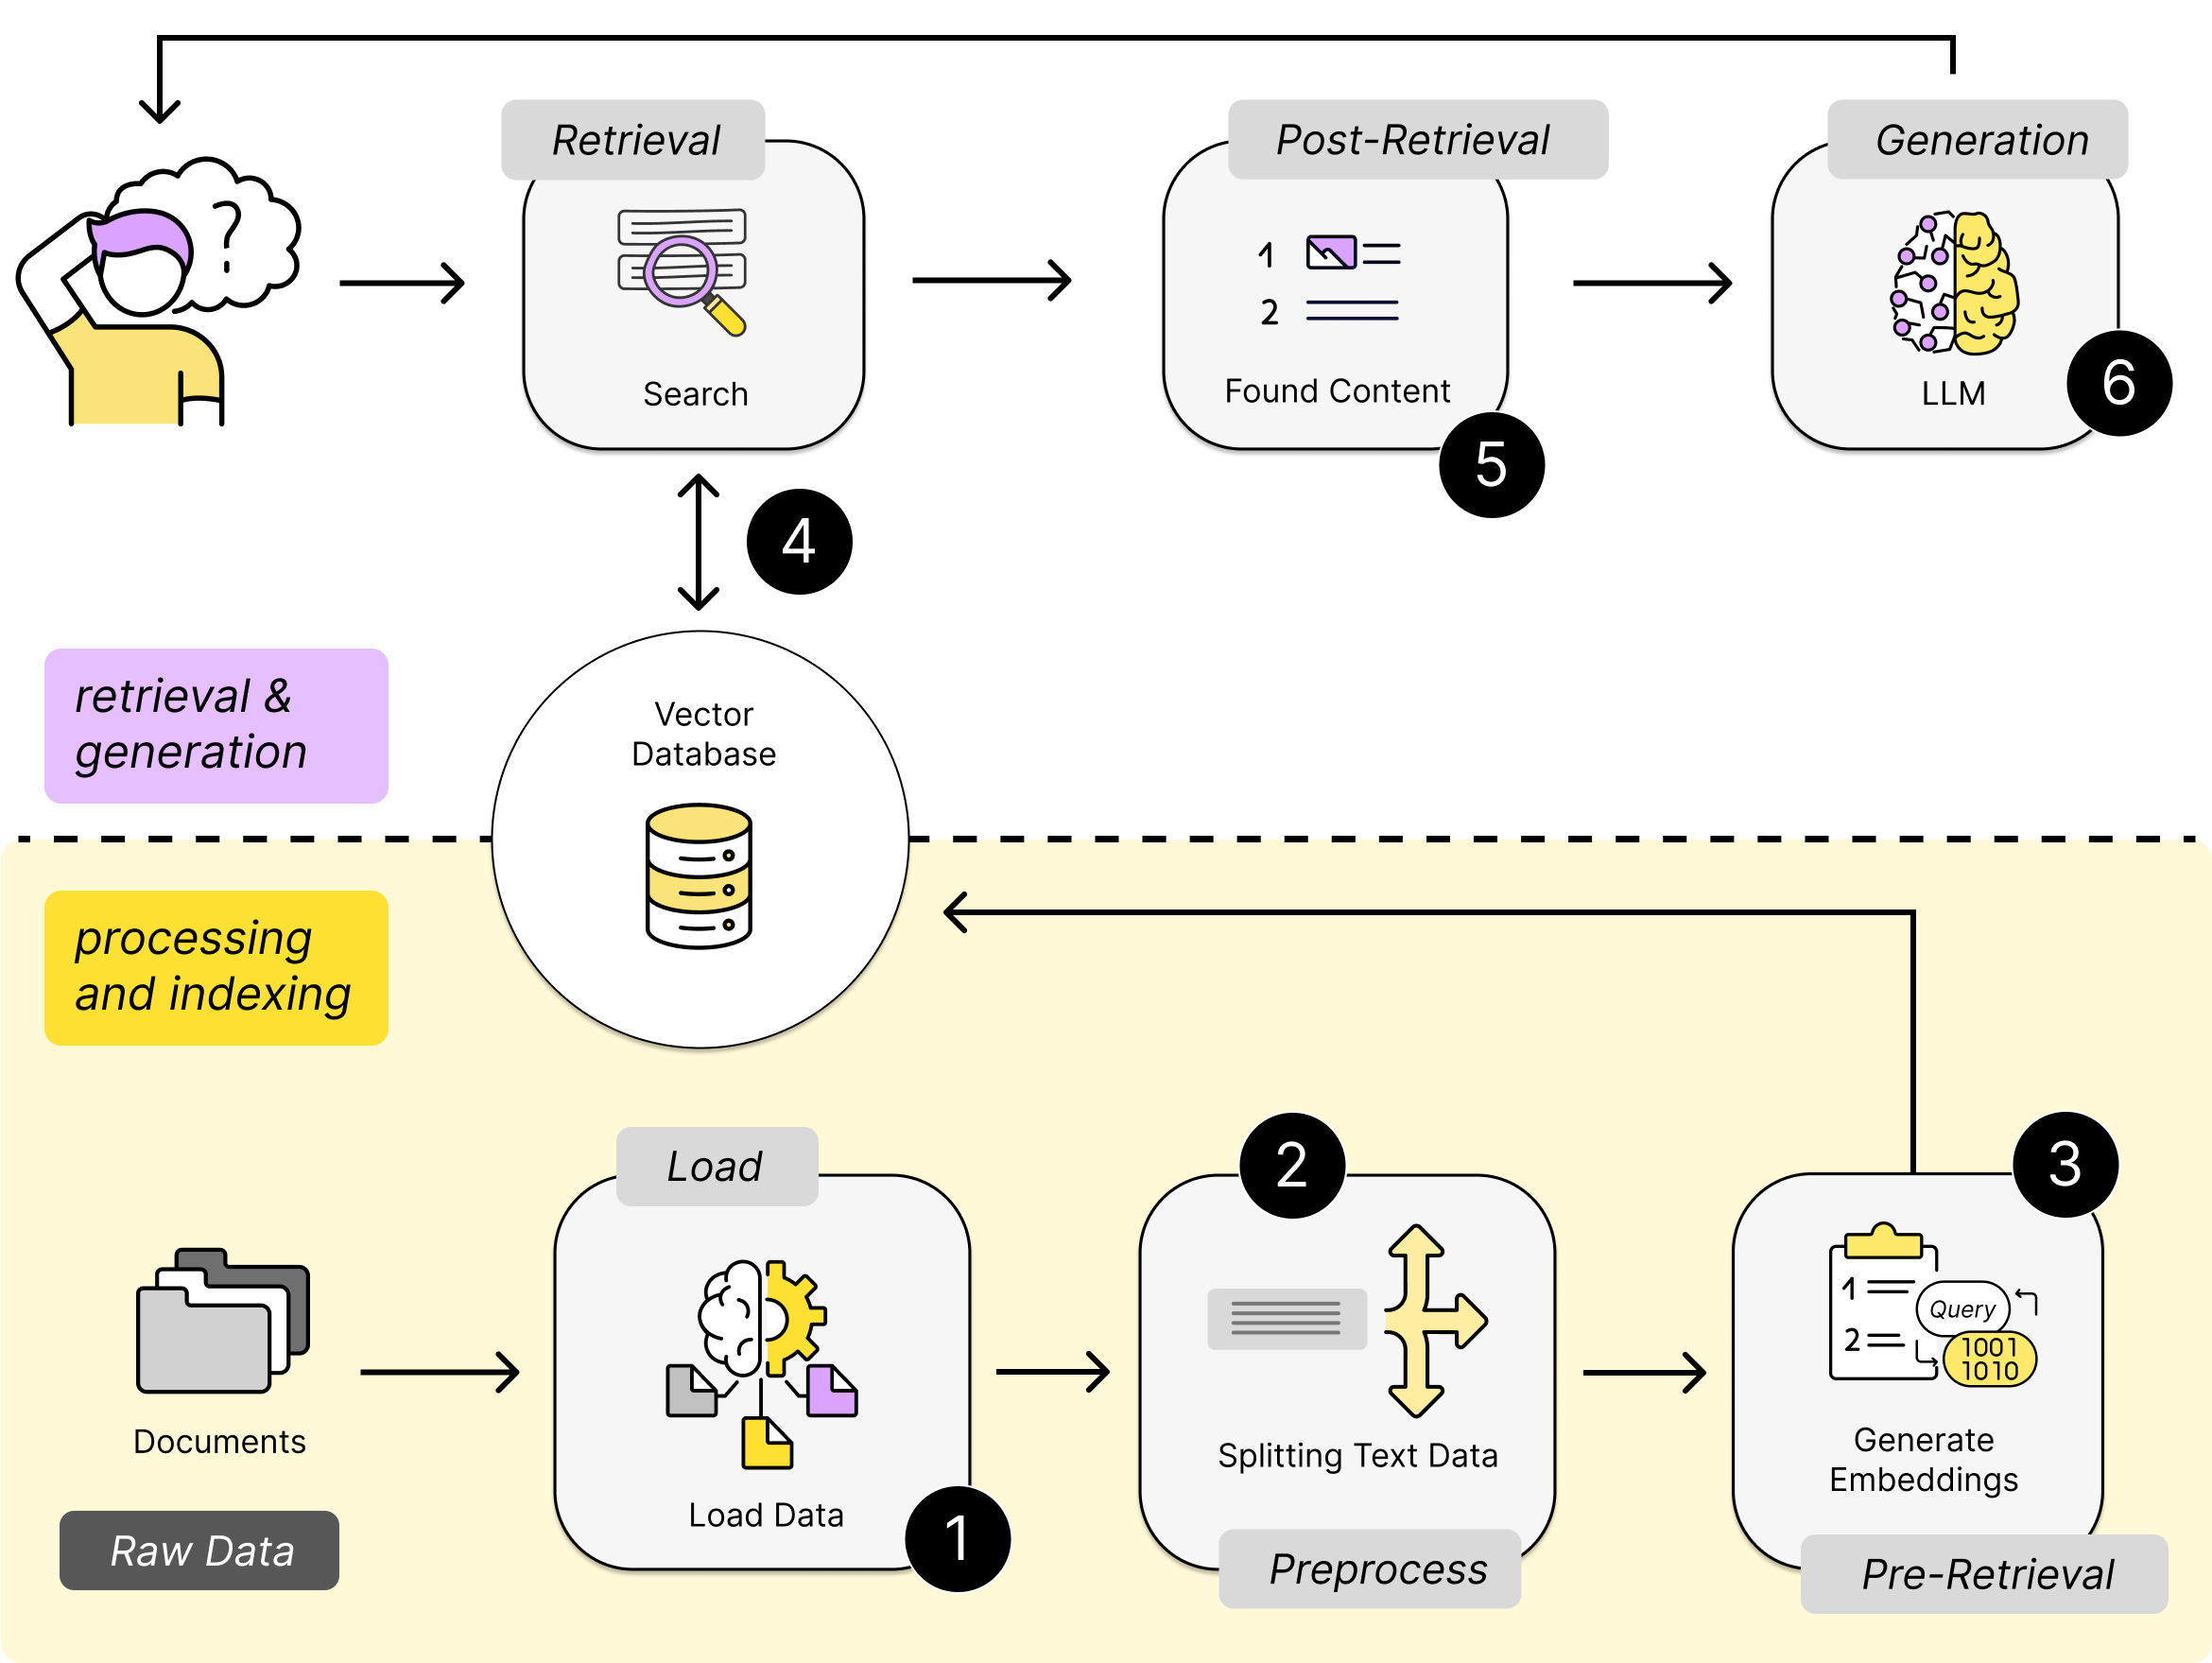

In [2]:
display(Image(filename="images/rwpc_0302.png", width=500, height=500))

summarizes the main components of a RAG system, showing both the indexing pipeline (loading and processing documents) and the runtime retrieval flow (retrieving relevant chunks and generating answers).

### Loading Word Files in Python

#### Problem
You want to load Word files into your RAG system.
#### Solution
Use python-docx for simple text extraction when you don’t need to distinguish element types. Use unstructured instead, when you need to preserve document structure (headings, paragraphs, lists, images) for targeted processing of the elements.

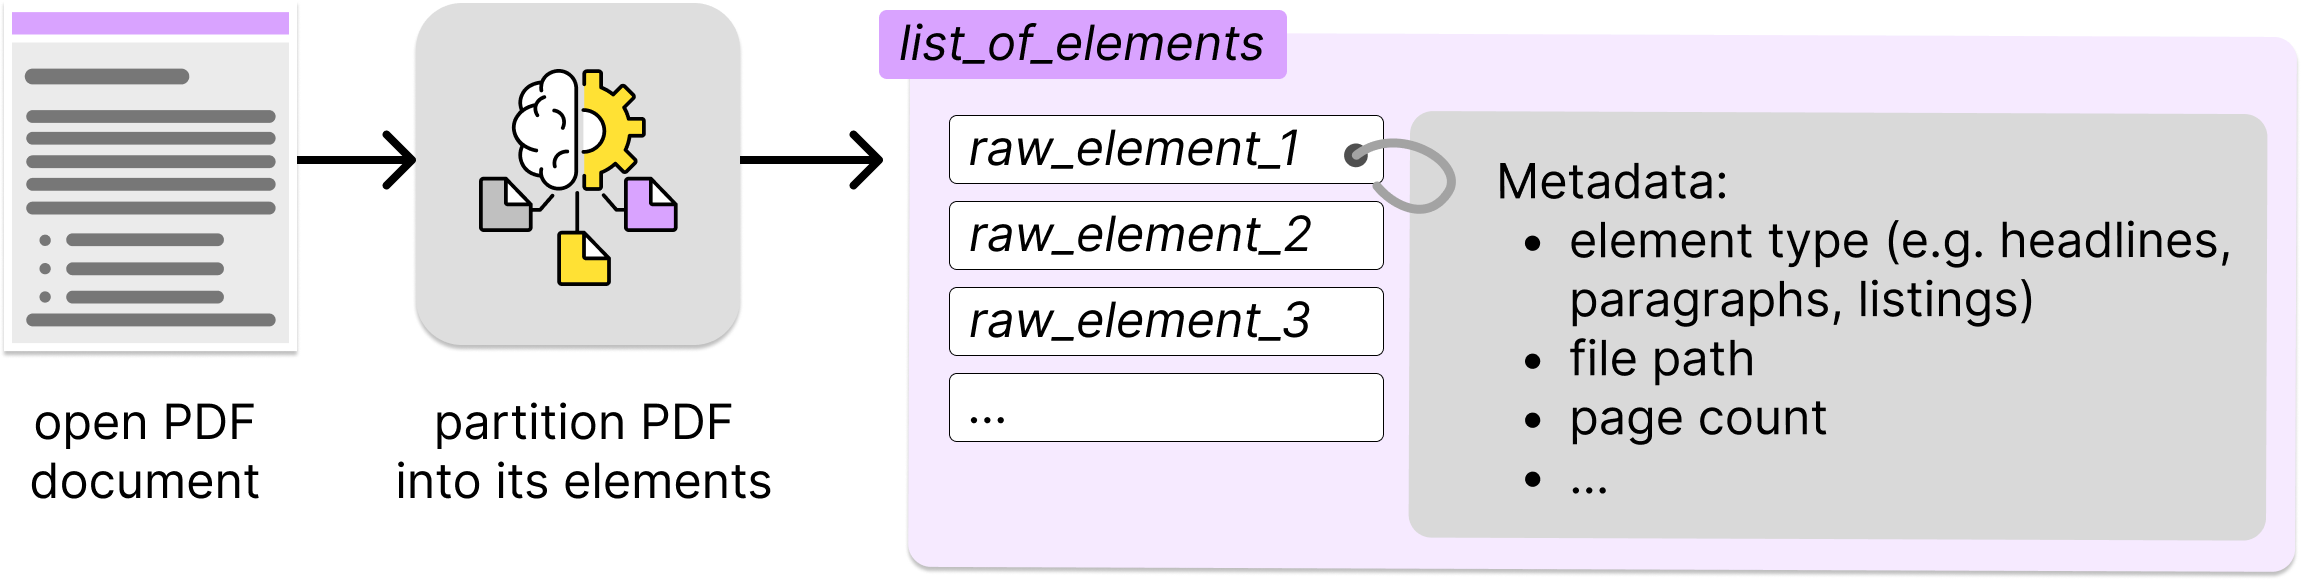

In [3]:
display(Image(filename="images/rwpc_0303.png", width=500, height=500))

Both approaches are demonstrated below. The first uses python-docx, the second uses unstructured. Both examples use pandas for further data processing. Install the required libraries:

### Loading PDF Files

### Problem
You want to load PDF files into your RAG system.

### Solution
The PyPDF2 library is an open-source library for splitting, merging, cropping, and transforming PDF pages. It uses Pillow to extract images.

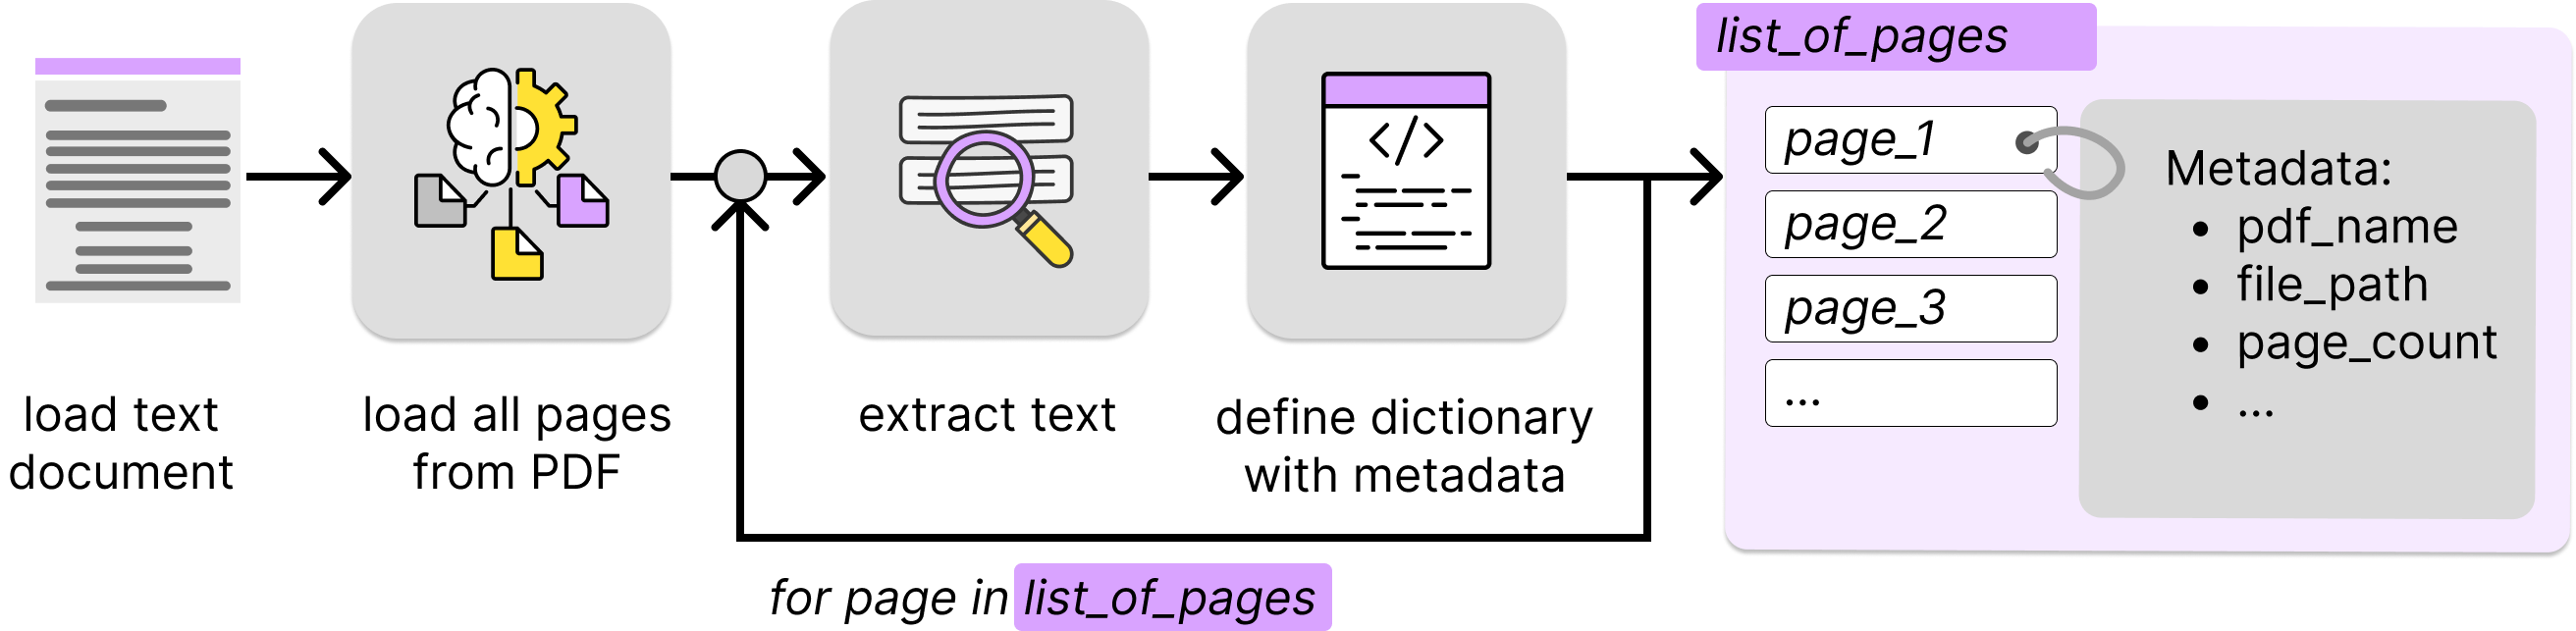

In [6]:
display(Image(filename="images/rwpc_0306.png", width=500, height=500))

###  Loading and Handling Tabular Data from Excel and CSV Files

In [7]:
## pip install openpyxl pandas

In [ ]:
import os
import pandas as pd

file_path = "../datasets/csv_files/census-income.xlsx"
df_excel = pd.read_excel(io=file_path)


def create_text_description_of_row(row):
    row["text_description"] = (
        f"""The candidate {row['age']} years old is working in the
            {row['workclass']} sector. The candidate was born in
            {row['native-country']}, is {row['marital-status']}
            and has a {row['relationship']} relationship.
            The candidate has a {row['education']} degree and is
            working as a {row['occupation']}. The income of the
            candidate is {row['income']}."""
    )
    return row
    
    
    # Apply the function create_text_description_of_row
    # to each row of the data frame
    df_extended = df_excel.apply(create_text_description_of_row, axis=1)


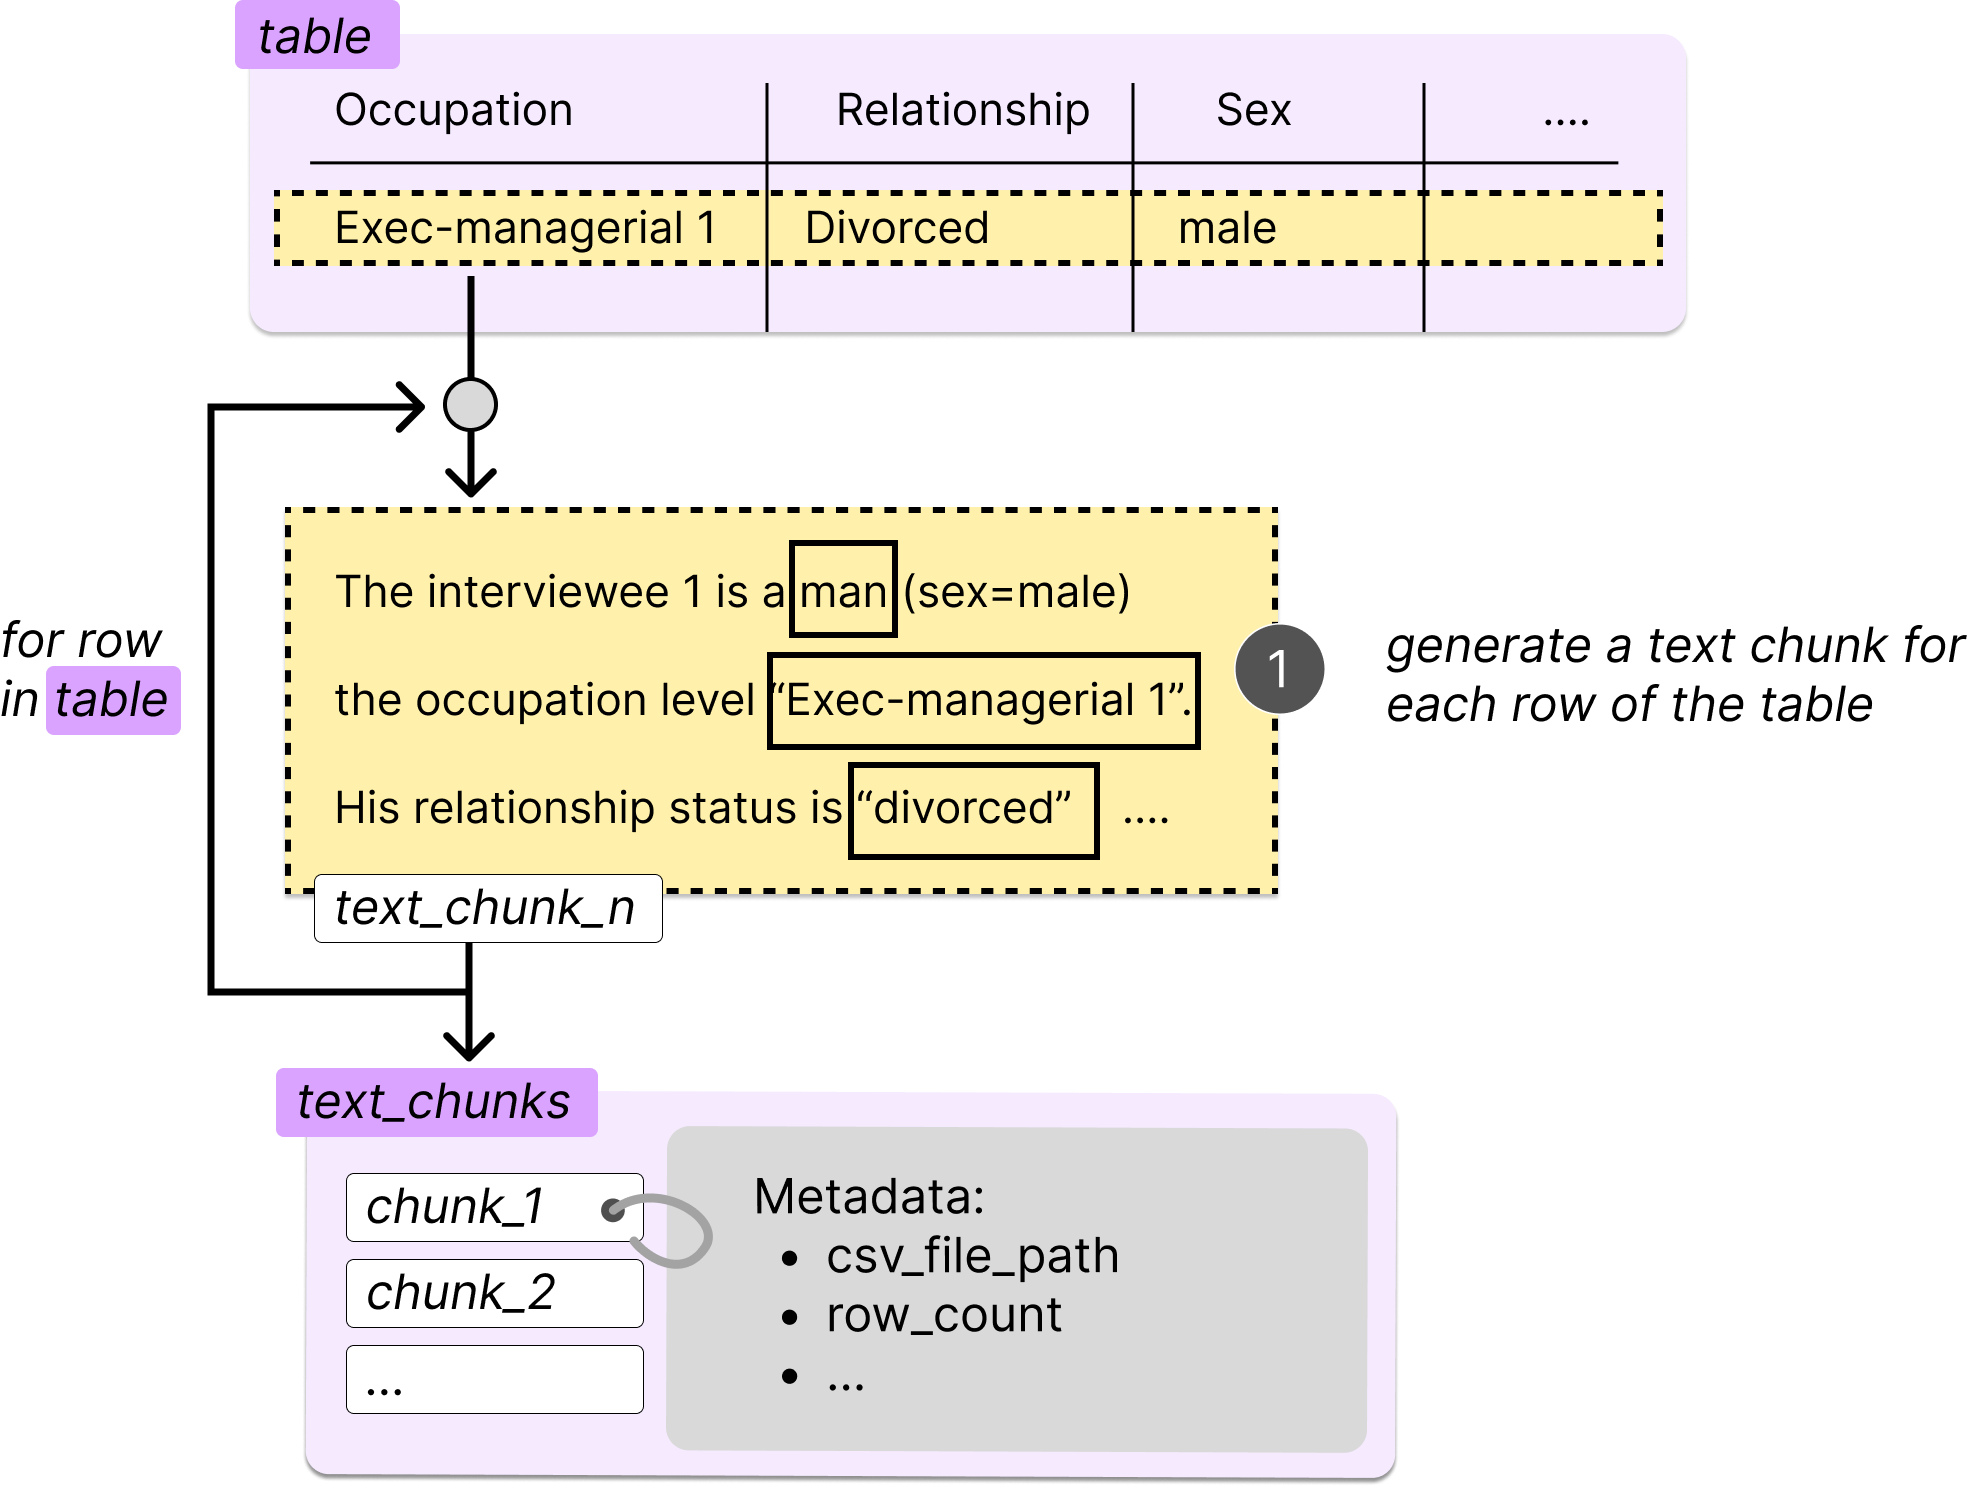

In [10]:
display(Image(filename="images/rwpc_0308.png", width=500, height=500))

### Embedding Tables in Prompts

As an alternative to converting rows into individual text snippets, you can embed the entire table directly into the LLM prompt. This works best for small tables where the full context fits into the model’s context window.

Note:
LLMs are not designed for numerical computation or complex data analysis. However, modern LLMs can often recognize simple patterns, compare values across rows and columns, and summarize trends at a useful level. Because the model sees the complete table, it can identify relationships that would be lost if only a few rows were retrieved.

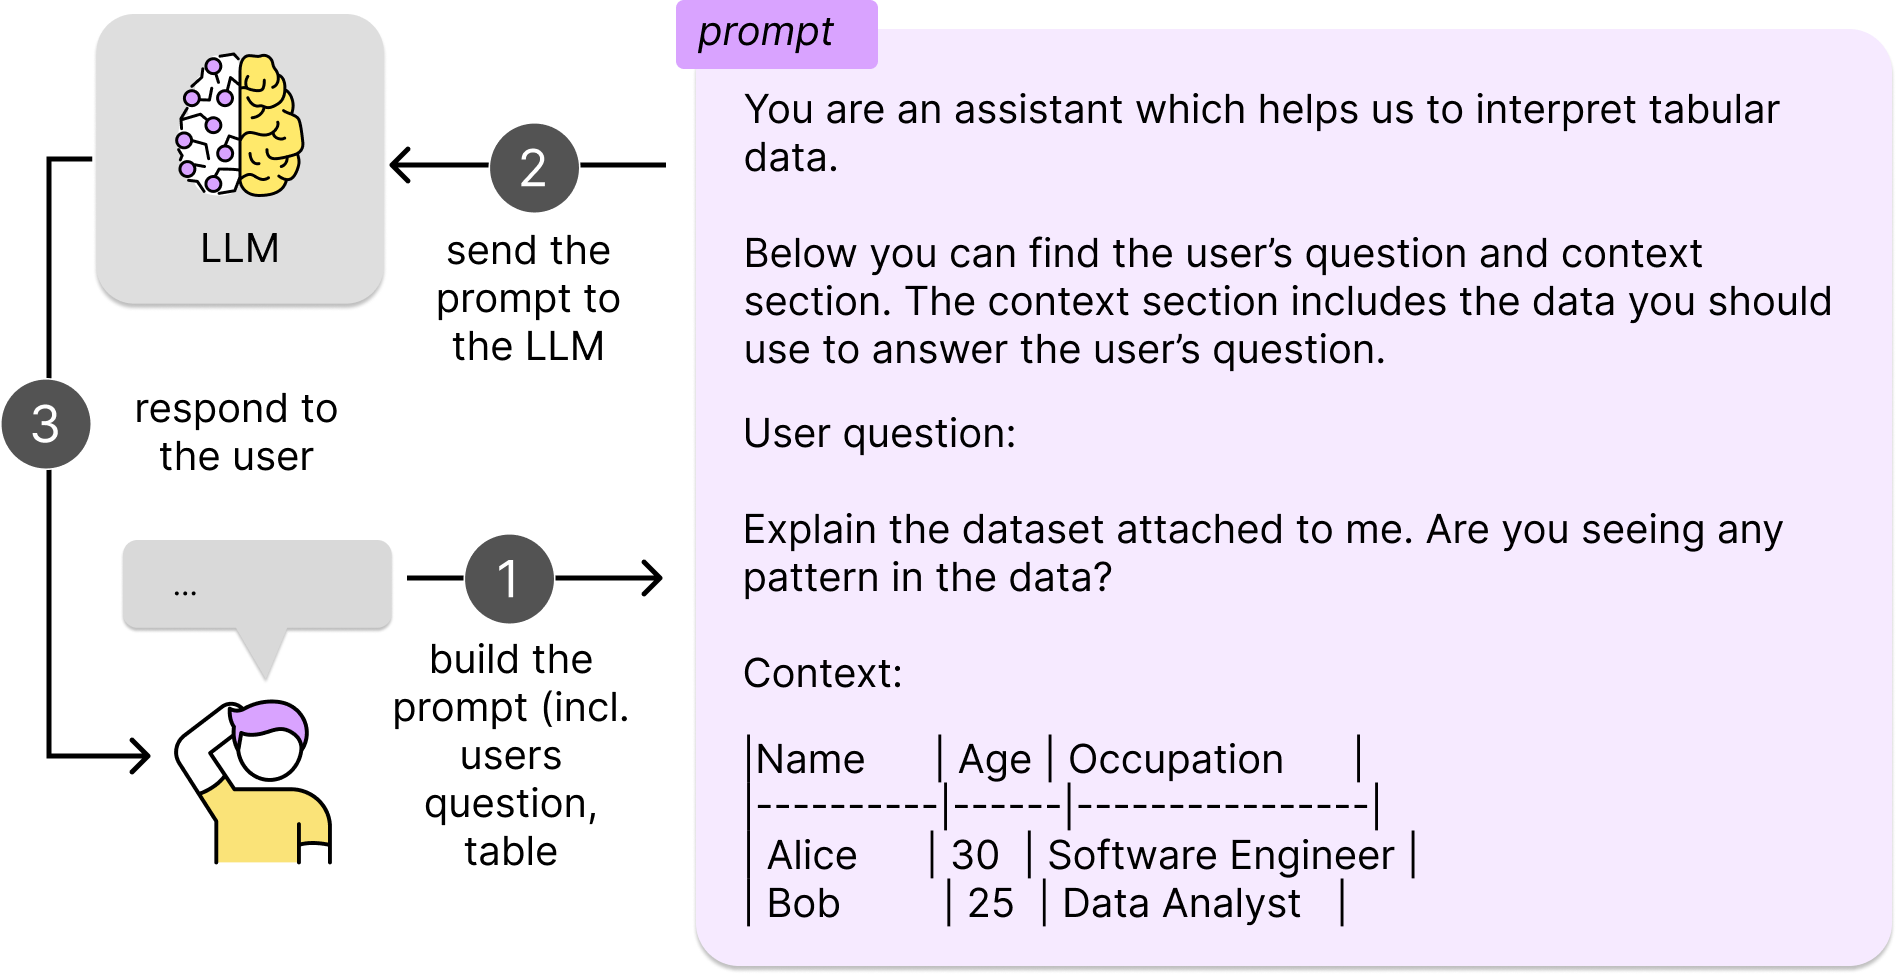

In [12]:
display(Image(filename="images/rwpc_0310.png", width=500, height=500))

### Text-to-SQL for Complex Queries

For complex analytical queries or large datasets, the Text-to-SQL approach is the most powerful option. The tabular data is uploaded to a SQL database. When a user asks a question, an LLM analyzes the table schema and the user’s question to generate an appropriate SQL query. The query results are then interpreted by the LLM to produce a natural language answer.

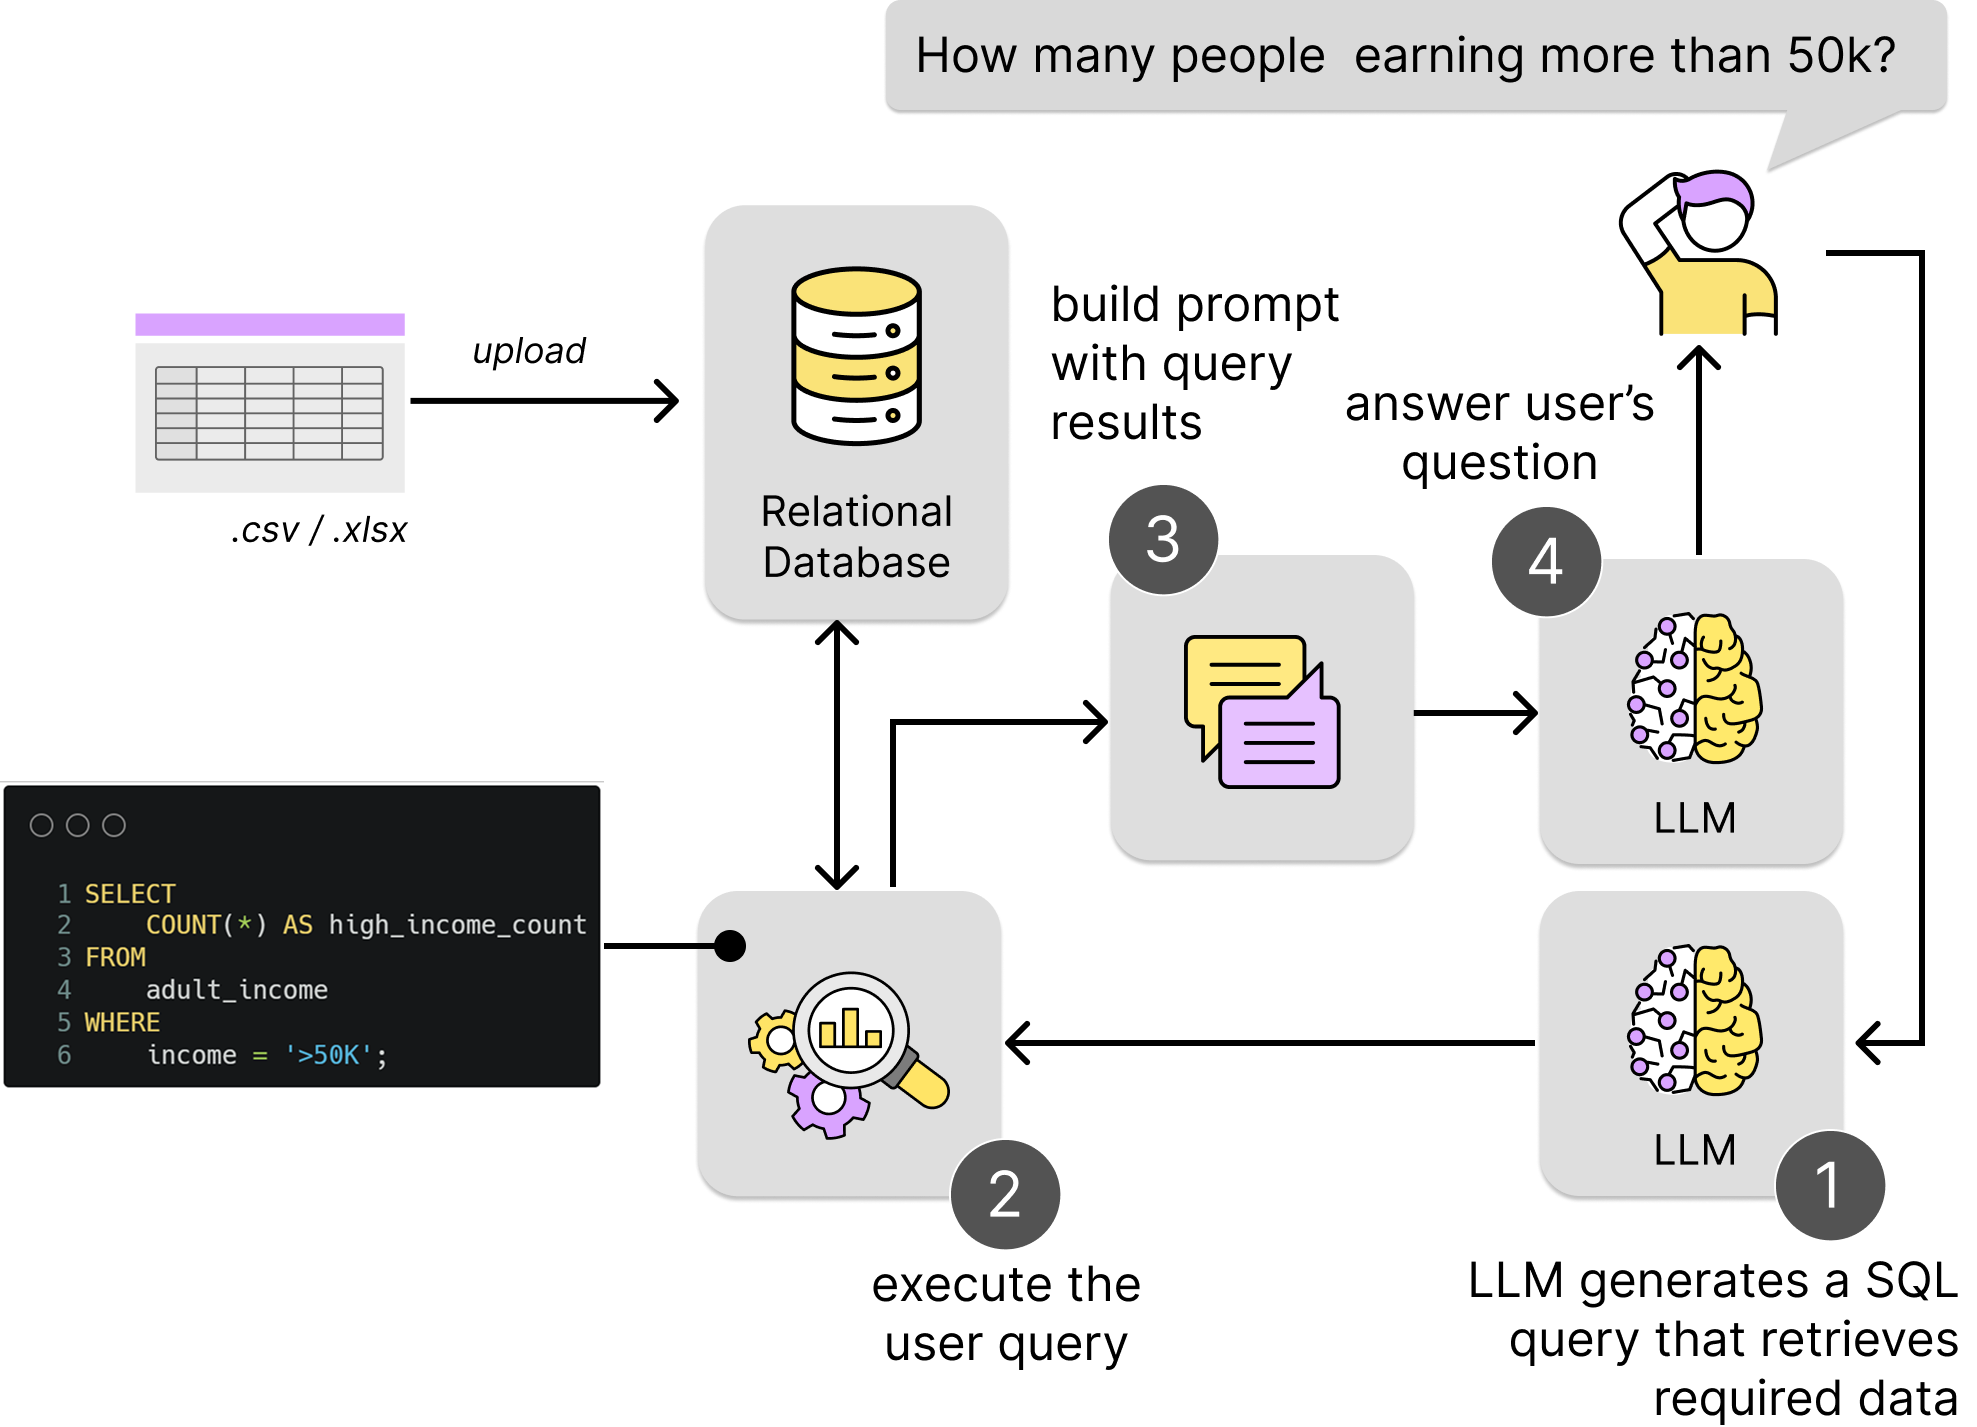

In [13]:
display(Image(filename="images/rwpc_0311.png", width=500, height=500))

In [1]:
!pip install python-docx==1.1.2
!pip install unstructured==0.17.2
!pip install python-magic-bin==0.4.14
!pip install pandas==2.2.3
!pip install PyPDF2==3.0.1
!pip install pillow==11.2.1
!pip install openpyxl==3.1.5
!pip install pdf2image==1.17.0
!pip install pytesseract==0.3.13
!pip install openai==1.82.1
!pip install python-dotenv==1.1.0
!pip install sqlalchemy==2.0.41
!pip install psycopg2-binary==2.9.10
!pip install moviepy==2.2.1
!pip install pdfminer.six==20250506
!pip install pi-heif==0.22.0
!pip install unstructured-inference==1.0.2


ERROR: Could not find a version that satisfies the requirement python-magic-bin==0.4.14 (from versions: none)
ERROR: No matching distribution found for python-magic-bin==0.4.14
  Using cached python_dotenv-1.1.0-py3-none-any.whl.metadata (24 kB)
Using cached python_dotenv-1.1.0-py3-none-any.whl (20 kB)
  Attempting uninstall: python-dotenv
    Found existing installation: python-dotenv 1.2.1
    Uninstalling python-dotenv-1.2.1:
      Successfully uninstalled python-dotenv-1.2.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 44.3 MB/s eta 0:00:00
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.47
    Uninstalling SQLAlchemy-2.0.47:
      Successfully uninstalled SQLAlchemy-2.0.47
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: moviepy
    Found existing installation: moviepy 1.0.3
    Uninstalling moviepy-1.0.3:


### Install Poppler

To use `pdf2image` you need to install `Poppler`.

**Installation instructions:**
- **Google Colab / Ubuntu / Debian:** Run the cell below
- **macOS:** Run `brew install poppler` in your terminal
- **Windows:** Download from [poppler-windows releases](https://github.com/oschwartz10612/poppler-windows/releases/) and add to PATH

In [2]:
import sys

# Check if running in Google Colab or Linux environment
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !apt-get update -qq
    !apt-get install -y -qq poppler-utils
    print("✓ Poppler installed successfully")
else:
    print("⚠ Running locally. Please install Poppler manually:")
    print("  - macOS: brew install poppler")
    print("  - Ubuntu/Debian: sudo apt-get install poppler-utils")
    print("  - Windows: Download from https://github.com/oschwartz10612/poppler-windows/releases/")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package poppler-utils.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...
✓ Poppler installed successfully


### Load sample files

This notebook uses sample Word and PDF files from the `datasets` directory.

When running on Google Colab, the code below will download the datasets from GitHub.

In [3]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !git clone --no-checkout https://github.com/polzerdo55862/RAG-with-Python-Cookbook.git
    %cd RAG-with-Python-Cookbook
    !git sparse-checkout init --cone
    !git sparse-checkout set datasets
    !git checkout
    !cp -r datasets /content/datasets
    print("✓ Datasets downloaded to /content/datasets")
else:
    print("⚠ Running locally. Using ../datasets/ directory")

Cloning into 'RAG-with-Python-Cookbook'...
remote: Enumerating objects: 1624, done.
remote: Counting objects: 100% (364/364), done.
remote: Compressing objects: 100% (174/174), done.
remote: Total 1624 (delta 244), reused 239 (delta 186), pack-reused 1260 (from 2)
Receiving objects: 100% (1624/1624), 42.78 MiB | 6.24 MiB/s, done.
Resolving deltas: 100% (928/928), done.
/content/RAG-with-Python-Cookbook
Updating files: 100% (88/88), done.
Your branch is up to date with 'origin/main'.
✓ Datasets downloaded to /content/datasets


### Load secrets

If you run this code in Google Colab, save your OpenAI API key in the secrets and access it by

In [4]:
import os
import sys
from dotenv import load_dotenv

# Check if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import userdata  # type: ignore

        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    except ModuleNotFoundError:
        pass
else:
    load_dotenv()

### 1.1 Loading Word Files in Python

Option 1: load word files using the `python_docx` library

In [5]:
import os
import requests
from docx import Document
from io import BytesIO

file_path = "../datasets/word_files/2023_Jan_7_Feature_Engineering_Techniques.docx"
doc = Document(file_path)

text = []
for paragraph in doc.paragraphs:
    text.append(paragraph.text)

full_text = "\n".join(text)


In [6]:
full_text

'\n7 of the Most Used Feature Engineering Techniques\nHands-on Feature Engineering with Scikit-Learn, Tensorflow, Pandas and Scipy\n7 of the most used Feature Engineering Techniques\u200a—\u200aImage by the author\n\nTable of content\nIntroduction\n1. Encoding\n 1.1 Label Encoding using Scikit-learn\n 1.2 One-Hot Encoding using Scikit-learn, Pandas and Tensorflow\n2. Feature Hashing\n 2.1 Feature Hashing using Scikit-learn\n3. Binning / Bucketizing\n 3.1 Bucketizing using Pandas\n 3.2 Bucketizing using Tensorflow\n 3.3 Bucketizing using Scikit-learn\n4. Transformer\n 4.1 Log-Transformer using Numpy\n 4.2 Box-Cox Function using Scipy\n5. Normalize / Standardize\n 5.1 Normalize and Standardize using Scikit-learn\n6. Feature Crossing\n 6.1 Feature Crossing in Polynomial Regression\n 6.2 Feature Crossing and the Kernel-Trick\n7. Principal Component Analysis (PCA)\n 7.1 PCA using Scikit-learn\nSummary\nReferences\n\nIntroduction\nFeature engineering describes the process of formulating rele

Option 2: load word files using the unstructured library

In [7]:
from unstructured.partition.docx import partition_docx
import os
import pandas as pd

# elements = partition_docx(filename=file_path)
elements = partition_docx(filename=file_path)

list_of_elements = []

for element in elements:
    element_dict = {
        "element_id": element.id,
        "file_path": file_path,
        "category": element.category,  # e.g. "Title", "NarrativeText", "ListItem"
        "text": element.text,
        "last_modified": element.metadata.last_modified,
    }

    list_of_elements.append(element_dict)

elements_df = pd.DataFrame(list_of_elements)

In [8]:
elements_df.head()

,element_id,file_path,category,text,last_modified
0,135f726911a68beceb56d92e2b9d10bc,../datasets/word_files/2023_Jan_7_Feature_Engi...,Title,7 of the Most Used Feature Engineering Techniques,2026-02-28T18:29:49
1,f275447183f11b993f2a87d4b428299b,../datasets/word_files/2023_Jan_7_Feature_Engi...,Title,Hands-on Feature Engineering with Scikit-Learn...,2026-02-28T18:29:49
2,9dacd0881e31b366756a6cc20884f661,../datasets/word_files/2023_Jan_7_Feature_Engi...,NarrativeText,7 of the most used Feature Engineering Techniq...,2026-02-28T18:29:49
3,3bec63fc43107e87aae98bbaf5313196,../datasets/word_files/2023_Jan_7_Feature_Engi...,Title,Table of content,2026-02-28T18:29:49
4,b1b29811f875047fef0bab817d6325c5,../datasets/word_files/2023_Jan_7_Feature_Engi...,UncategorizedText,Introduction,2026-02-28T18:29:49


### 1.2 Loading PDF Files

In [9]:
import PyPDF2
import os
import pandas as pd

file_path = "../datasets/pdf_files/2023_Jan_7_Feature_Engineering_Techniques.pdf"

with open(file_path, "rb") as file:
    reader = PyPDF2.PdfReader(file)

    # Initialize an empty string to store the extracted text
    list_of_pages = []
    page_counter = 1

    for page in reader.pages:
        page_dict = {
            "file_name": reader.metadata.get("/Title"),
            "producer": reader.metadata.get("/Producer"),
            "page_number": page_counter,
            "text": page.extract_text(),
            "images": page.images,
        }

        list_of_pages.append(page_dict)

        page_counter += 1

# Convert the list of pages to a pandas DataFrame
pages_df = pd.DataFrame(list_of_pages)

In [10]:
# Display the first few rows of the DataFrame
pages_df.head()

,file_name,producer,page_number,text,images
0,2023_Jan_7_Feature_Engineering_Techniques,Skia/PDF m131 Google Docs Renderer,1,7\nof\nthe\nMost\nUsed\nFeature\nEngineering\n...,"[File(name=X7.png, data: 2.2 kB)]"
1,2023_Jan_7_Feature_Engineering_Techniques,Skia/PDF m131 Google Docs Renderer,2,3.2\nBucketizing\nusing\nTensorflow\n3.3\nBuck...,[]
2,2023_Jan_7_Feature_Engineering_Techniques,Skia/PDF m131 Google Docs Renderer,3,A\nstandard\nMachine\nLearning\npipeline — Ins...,"[File(name=X17.png, data: 692 Byte)]"
3,2023_Jan_7_Feature_Engineering_Techniques,Skia/PDF m131 Google Docs Renderer,4,"●\nI\nn\nthe\nsupply\nchain\ncontext\n,\nevery...","[File(name=X20.png, data: 2.6 kB)]"
4,2023_Jan_7_Feature_Engineering_Techniques,Skia/PDF m131 Google Docs Renderer,5,Once\nwe\nhave\nenough\ndata\nthat\ndescribes\...,"[File(name=X26.png, data: 1.5 kB)]"


### 1.3 Loading and Handling CSV and Excel Files

In [11]:
import os
import pandas as pd

file_path = "../datasets/csv_files/census-income.xlsx"
df_excel = pd.read_excel(io=file_path)


def create_text_description_of_row(row):
    row["text_description"] = (
        f"""The candidate {row['age']} years old is working in the
            {row['workclass']} sector. The candidate was born in
            {row['native-country']}, is {row['marital-status']}
            and has a {row['relationship']} relationship.
            The candidate has a {row['education']} degree
            and is working as a {row['occupation']}.
            The income of the candidate is {row['income']}."""
    )

    return row


# Apply the function create_text_description_of_row to each row of the data frame
df_extended = df_excel.apply(create_text_description_of_row, axis=1)


In [12]:
# Display the first 5 text_description of the dataset
df_extended["text_description"].head()

,text_description
0,The candidate 39 years old is working in the\n...
1,The candidate 50 years old is working in the\n...
2,The candidate 38 years old is working in the\n...
3,The candidate 53 years old is working in the\n...
4,The candidate 28 years old is working in the\n...


In [13]:
df_extended["text_description"][0]

'The candidate 39 years old is working in the\n            State-gov sector. The candidate was born in\n            United-States, is Never-married\n            and has a Not-in-family relationship.\n            The candidate has a Bachelors degree\n            and is working as a Adm-clerical.\n            The income of the candidate is <=50K.'

### 1.4 Querying a PostgreSQL Database

This section needs a PostgreSQL database to connect to.

**Note:** Make sure a PostgreSQL server is installed and running, either locally on your machine or on a remote host that you can connect to.

```
CREATE USER rag_user WITH PASSWORD 'raguserpassword123';
GRANT ALL ON ALL TABLES IN SCHEMA public TO rag_user;
```

### 1.5 Loading Audio Files by Using Speech-to-Text Models

In [15]:
import os
from openai import OpenAI

audio_file_path = "../datasets/audio_files/harvard.wav"

# initialize the OpenAI client with your API key
client = OpenAI()

with open(audio_file_path, "rb") as audio_file:
    transcription = client.audio.transcriptions.create(
        model="whisper-1", file=audio_file
    )

transcription

Transcription(text='The stale smell of old beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun.', logprobs=None, usage={'type': 'duration', 'seconds': 19})

### 1.6 Extracting Text from Images and PDFs Using OCR

In [17]:
import os
from pdf2image import convert_from_path
from PIL import Image
import pytesseract

image = Image.open(
    fp="../datasets/images/example_finance_reporting_slide.png"
)

text = pytesseract.image_to_string(image)
text

'Sales volume growth driven by EMEA 18/19\n\nBusiness Development\n1,926\n\n628 e Sales volume growth driven by\n\nEMEA with sales activity up to 2.3x\nYoY\n\ne Sales activity in 20 countries during\nQ2 19\n« US (28%), Spain (20%), India\n(15%) and Norway (11%) are the\nmain contributors to the Q2 19\nsales volume\n\n~\nWw\nx\n—\n®\n£\n2\n3\n>\n1)\n2\n©\n”\n\nQ4 18 Q119\n\nAmericas J EMEA\n\n \n\n \n\n \n\x0c'

In [20]:
import os
from pdf2image import convert_from_path
from PIL import Image
import pytesseract

file_path = (
    "../datasets/pdf_files/2023_Jan_7_Feature_Engineering_Techniques.pdf"
)

images = convert_from_path(pdf_path=file_path)

text = []
for i, image in enumerate(images):
    page_text = pytesseract.image_to_string(image)
    text.append(page_text)

print(text)

['7 of the Most Used Feature Engineering Techniques\n\nHands-on Feature Engineering with Scikit-Learn, Tensorflow, Pandas and Scipy\n\n \n\n \n\n \n\n \n\n \n\n \n\n \n\n \n\n \n\n \n\n \n\n \n\n7 of the most used Feature Engineering Techniques—Image by the author\n\nTable of content\n\nIntroduction\n\n1. Encoding\n\n1.1 Label Encoding using Scikit-learn\n\n1.2 One-Hot Encoding using Scikit-learn, Pandas and Tensorflow\n2. Feature Hashing\n\n2.1 Feature Hashing using Scikit-learn\n\n3. Binning / Bucketizing\n\n3.1 Bucketizing using Pandas\n\x0c', '3.2 Bucketizing using Tensorflow\n\n3.3 Bucketizing using Scikit-learn\n\n4. Transformer\n\n4.1 Log-Transformer using Numpy\n\n4.2 Box-Cox Function using Scipy\n\n5. Normalize / Standardize\n\n5.1 Normalize and Standardize using Scikit-learn\n6. Feature Crossing\n\n6.1 Feature Crossing in Polynomial Regression\n6.2 Feature Crossing and the Kernel-Trick\n\n7. Principal Component Analysis (PCA)\n\n7.1 PCA using Scikit-learn\n\nSummary\n\nRefere

### 1.7 Extracting Text from Images using Multimodal Models

In [21]:
import os
import base64
from openai import OpenAI

png_file_path = "../datasets/images/example_finance_reporting_slide.png"

# initialize the OpenAI client
client = OpenAI()

with open(png_file_path, "rb") as image_file:
    base64_image = base64.b64encode(image_file.read()).decode("utf-8")

    prompt = (
        "Extract the text from the image attached. Make sure to only "
        "extract only the text. If there is no text in the image, "
        "please return with the sentence 'No text found in the image."
    )

    response = client.chat.completions.create(
        model="gpt-4o-mini",  # define the model to use
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": (
                                f"data:image/jpeg;base64,"
                                f"{base64_image}"
                            ),
                        },
                    },
                ],
            }
        ],
        max_completion_tokens=500,
    )

    content = response.choices[0].message.content
    print(content)

Sales volume growth driven by EMEA 18/19

Business Development

• Sales volume growth driven by EMEA with sales activity up to 2.3x YoY

• Sales activity in 20 countries during Q2 19
  • US (28%), Spain (20%), India (15%) and Norway (11%) are the main contributors to the Q2 19 sales volume


### 1.8 Generating Text Summaries for Images Using Multimodal Models

In [22]:
import os
import base64
from openai import OpenAI

image_path = "../datasets/images/vietnam.png"

# initialize the OpenAI client
client = OpenAI()

with open(image_path, "rb") as image_file:
    base64_image = base64.b64encode(image_file.read()).decode("utf-8")

    prompt = (
        "You are an assistant for visually impaired users. "
        "Describe the image in detail."
    )

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": (
                                f"data:image/jpeg;base64,"
                                f"{base64_image}"
                            ),
                        },
                    },
                ],
            }
        ],
        max_completion_tokens=150,
    )

    content = response.choices[0].message.content
    print(content)

The image showcases a vibrant city skyline at dusk. The scene is set by a river, reflecting the buildings and lights in its smooth surface. 

On the left side, there’s a pier with several boats, hinting at a waterfront area that seems bustling. As you move towards the center, the skyscrapers dominate the skyline, featuring various architectural styles and heights. The tallest tower has a sleek, modern design that narrows at the top, creating a distinctive shape.

The buildings are adorned with numerous windows that glow warmly as night approaches, and some are lit in vibrant colors, adding a lively ambiance. The backdrop consists of a gradient sky transitioning from deep blue to soft purples and light pinks, indicating the setting sun. 

Overall, the


### 1.9 Generating Text Summaries for Embedded Tables Using Multimodal Models

The following code will use OCR and by default will use `unstructured_pytesseract`. Run the following to install `tessearct-ocr`.

In [23]:
!apt-get update -qq
!apt-get install -y -qq tesseract-ocr poppler-utils

!pip install -q "unstructured[pdf]" unstructured_pytesseract


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.2/538.2 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.4 MB/s eta 0:00:00


In [24]:
import os
from unstructured.partition.pdf import partition_pdf

pdf_file_path = "../datasets/pdf_files/adult_data_article.pdf"

tables = []
texts = []

# partition the PDF file into its elements
raw_pdf_elements = partition_pdf(
    filename=pdf_file_path,
    strategy="hi_res",
)

for element in raw_pdf_elements:
    if "unstructured.documents.elements.Table" in str(type(element)):
        tables.append(str(element))

yolox_l0.05.onnx:   0%|          | 0.00/217M [00:00<?, ?B/s]

In [25]:
from openai import OpenAI
import pandas as pd


def summarize_tables(row):
    summary_prompt = (
        f"You are an assistant tasked with summarizing tables. "
        f"Give a concise summary of the table. "
        f"Table chunk: {row.table}"
    )

    # Initialize the OpenAI API client and generate table summary
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": summary_prompt}],
        temperature=0.7,
        max_tokens=150,
    )

    row["table_summary"] = response.choices[0].message.content

    return row


# create a pandas dataframe from the tables
tables_df = pd.DataFrame(tables, columns=["table"])

# add a column to the dataframe to store the summaries
tables_df = tables_df.apply(summarize_tables, axis=1)

In [27]:
# define a random question to the embedded table
user_question = "What are the education levels of the people working in Sales?"


def build_prompt_and_generate_answer(user_question, found_table):
    """
    This function builds a prompt using the user's question and the context of the table
    and generates an answer using the OpenAI API

    Parameters:
        user_question: the question asked by the user
        found_table: the table context to generate the answer from

    Returns:
        answered_question: the answer to the user's question
    """

    question_prompt = f"""You are an assistant using the content from PDFs \
                        to answer questions. Below you can find the \
                        user's question and relevant context. Please use the \
                        context to generate an answer to the user's question.

                        # User question: {user_question}

                        # Context:

                        ## Table summary:
                        {found_table.table_summary}

                        ## Table content:
                        {found_table.table}""".strip()

    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

    answered_question = (
        client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": question_prompt}],
            temperature=0.7,
            max_tokens=150,
        )
        .choices[0]
        .message.content
    )

    return answered_question


# generate the answer to the user's question
# as context we using the first entry in the tables_df
answered_question = build_prompt_and_generate_answer(
    user_question=user_question, found_table=tables_df.iloc[0]
)

print(answered_question)

The education levels of people working in sales, based on the provided table content, are as follows:

1. Some-college
2. HS-grad
3. Some-college
4. Bachelors


### 1.10 Parsing PDFs with Multiple Media Content Using Unstructured and Multimodal Models

In [28]:
from unstructured.partition.pdf import partition_pdf
import os

# set the OCR agent to tesseract
os.environ["OCR_AGENT"] = "tesseract"

pdf_file_path = "../datasets/pdf_files/adult_data_article.pdf"
image_output_dir = "../datasets/extracted_content_from_pdfs/images"

# create output directory if it doesn't exist
os.makedirs(image_output_dir, exist_ok=True)

# get elements using the function extract_pdf_elements
raw_pdf_elements = partition_pdf(
    filename=pdf_file_path,
    extract_images_in_pdf=True,
    extract_image_block_types=["Image", "Table"],
    extract_image_block_to_payload=False,
    extract_image_block_output_dir=image_output_dir,
)

# categorize elements by type
tables = []
texts = []
titles = []

# fill the just created lists with the elements
for element in raw_pdf_elements:
    element_type = str(type(element))
    if "unstructured.documents.elements.Table" in element_type:
        tables.append(str(element))
    elif "unstructured.documents.elements.NarrativeText" in element_type:
        texts.append(str(element))
    elif "unstructured.documents.elements.Title" in element_type:
        titles.append(str(element))

### 1.11 Loading Videos Using Speech-to-Text and Multimodal Models

You can find the test video used in this example on YouTube:  
[Learn Data Science Tutorial – Full Course for Beginners](https://www.youtube.com/watch?v=ua-CiDNNj30)

> **Note:** The MP4 file is not included in this repository due to its size.

In [ ]:
import os
import pandas as pd

from moviepy import VideoFileClip, TextClip, CompositeVideoClip

video_file_path = "../datasets/videos/learn-data-science-tutorial.mp4"
image_output_folder = "../datasets/videos/video_extracted_images"

# create output folder if it doesn't exist
os.makedirs(image_output_folder, exist_ok=True)

clip = VideoFileClip(video_file_path)

# create a list of timestamps from which to extract a frame
time_step = 10  # time in seconds
timestamps = list(range(0, int(clip.duration) - time_step, time_step))

# for each timestamp extract a frame
for timestamp in timestamps:
    frame_image_path = os.path.join(
        image_output_folder, f"frame_{timestamp}.png"
    )
    clip.save_frame(frame_image_path, t=timestamp)

In [ ]:
# for each timestamp extract the audio sequence and save it to a .mp3 file
audio_output_folder = "../datasets/videos/video_extracted_audio"

# create output folder if it doesn't exist
os.makedirs(audio_output_folder, exist_ok=True)

for timestamp in timestamps:
    audio_clip = clip.subclip(timestamp, timestamp + time_step).audio
    output_audio_path = os.path.join(
        audio_output_folder, f"audio_{timestamp}.mp3"
    )
    audio_clip.write_audiofile(output_audio_path)

In [ ]:

from openai import OpenAI


def audio_to_text(audio_path):
    """
    Convert audio to text using OpenAI's Whisper model.

    Parameters:
    audio_path (str): The path to the audio file.

    Returns:
    str: The text recognized from the audio.

    """
    # Initialize the OpenAI client with your API key

    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

    # Open and read the audio file
    with open(audio_path, "rb") as audio_file:
        # Transcribe
        transcription = client.audio.transcriptions.create(
            model="whisper-1", file=audio_file
        )

    # save the transcription to a text file
    text_file_path = audio_path.replace(".mp3", ".txt")
    with open(text_file_path, "w") as text_file:
        text_file.write(transcription.text)

    return


# List all files in folder audio_output_folder
audio_files = os.listdir(audio_output_folder)

for audio_file in audio_files:
    absolut_path_audio_file = os.path.join(audio_output_folder, audio_file)
    # Use the function audio_to_text to convert the audio to text
    audio_to_text(audio_path=absolut_path_audio_file)